# YOLO26 — Frozen 커스텀 데이터셋 학습 & 예측

`13_Yolov3_train_frozen _최종.ipynb`의 **Frozen(겨울왕국) 캐릭터** 데이터셋을  
**Ultralytics YOLO26** 모델로 학습하고 예측하는 예제입니다.

| 항목 | 설명 |
|------|------|
| 데이터 | `frozen.zip` — 이미지 30장 + YOLO 라벨 |
| 설정 | `frozen.yaml` — 클래스 3개 (Anna, Elsa, Olaf) |
| 모델 | **YOLO26s** (`yolo26s.pt` — 30장 소규모 데이터에 적합) |
| 환경 | **Google Colab** / **Windows 로컬** 공통 |

### 데이터셋 구조 (frozen.zip 압축 해제 후)
```
frozen/
├── images/train/   # 01.jpg ~ 30.jpg
└── labels/train/   # 01.txt ~ 30.txt (YOLO 정규화 좌표)
```

> 원본 노트북과 동일하게 train/val 모두 `images/train`을 사용합니다.  
> (이미지 30장 규모의 소규모 데이터셋이므로 별도 val 분할 없이 진행)

## 0. 환경 설정

| 환경 | 준비 사항 |
|------|----------|
| **Colab** | GPU 런타임 선택, `frozen.zip`·`frozen.yaml`을 노트북과 같은 폴더에 업로드 |
| **Windows 로컬** | 이 노트북이 있는 폴더에 `frozen.zip`, `frozen.yaml`이 있어야 함 |

In [ ]:
# =============================================================================
#   Ultralytics 패키지 설치
# - YOLO26 API는 ultralytics 패키지에 포함되어 있습니다.
# - 최초 1회 실행하거나, 버전 업데이트가 필요할 때 주석(#)을 제거하고 실행하세요.
# - Colab / Windows 로컬 모두 pip install 로 동일하게 설치합니다.
# =============================================================================
# %pip install -U ultralytics


In [ ]:
# =============================================================================
#   라이브러리 임포트 및 실행 환경 설정
# - Colab / Windows 로컬을 자동 감지하고, GPU 사용 가능 여부를 확인합니다.
# - 이후 모든 셀에서 공통으로 사용하는 경로·상수를 여기서 정의합니다.
# =============================================================================

import sys
import zipfile
from pathlib import Path

import torch
import yaml
from IPython.display import Image, display  # 노트북 내 이미지 출력용
from ultralytics import YOLO, __version__

# ── 1) 실행 환경 감지 ───────────────────────────────────────────
# google.colab 모듈 존재 여부로 Colab / 로컬 Jupyter·VS Code 구분
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

IS_WINDOWS = sys.platform.startswith("win")

# ── 2) 연산 장치(Device) ───────────────────────────────────────
# CUDA GPU가 있으면 0번 GPU, 없으면 CPU 사용
DEVICE = 0 if torch.cuda.is_available() else "cpu"

# ── 3) 경로 설정 ───────────────────────────────────────────────
# Colab  : /content  (업로드 파일 기본 위치)
# 로컬   : 노트북 실행 현재 작업 디렉터리 (Path.cwd())
ROOT = Path("/content") if IN_COLAB else Path.cwd()
DATASET_DIR = ROOT / "frozen"          # 압축 해제 후 데이터셋 루트
ZIP_PATH = ROOT / "frozen.zip"         # 이미지+라벨 압축 파일
YAML_SRC = ROOT / "frozen.yaml"        # 원본 데이터셋 설정 파일
YAML_DST = DATASET_DIR / "frozen.yaml" # 환경에 맞게 경로 갱신된 yaml

# ── 4) 모델·추론 설정 ─────────────────────────────────────────
# yolo26s : 30장 소규모 커스텀 데이터에 적합 (yolo26n은 Anna confidence 낮음)
MODEL_NAME = "yolo26s.pt"
CONF_THRESH = 0.3  # 탐지 confidence 임계값 (13번 YOLOv3 노트북과 동일)

# ── 5) 환경 정보 출력 ─────────────────────────────────────────
print(f"실행 환경  : {'Google Colab' if IN_COLAB else '로컬'}")
print(f"OS         : {'Windows' if IS_WINDOWS else sys.platform}")
print(f"Ultralytics: {__version__}")
print(f"PyTorch    : {torch.__version__}")
print(f"Device     : {DEVICE} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")
print(f"ROOT       : {ROOT.resolve()}")

# Colab에서 GPU 런타임 선택 여부 확인
if IN_COLAB:
    !nvidia-smi


실행 환경  : 로컬
OS         : Windows
Ultralytics: 8.4.46
PyTorch    : 2.11.0+cu126
Device     : 0 (NVIDIA GeForce RTX 3060)
ROOT       : C:\MyCursorLab\06_Object_Detection


## 1. 데이터셋 준비 (frozen.zip 압축 해제 & YAML 경로 설정)

원본 `frozen.yaml`은 Colab 경로(`/content/frozen/...`)로 작성되어 있으므로,  
실행 환경에 맞게 경로를 자동 갱신합니다.

In [ ]:
# =============================================================================
#   데이터셋 준비 함수 + 실행
# - frozen.zip 압축 해제, frozen.yaml 경로 갱신
# - show_result() : 4번 예측 셀에서 결과 이미지를 노트북에 표시하는 헬퍼
# =============================================================================


def show_result(result, source_name: str, width: int = 600):
    """
    predict() 결과를 노트북에 이미지로 표시합니다.

    Parameters
    ----------
    result : ultralytics.engine.results.Results
        model.predict() 반환값 중 첫 번째 이미지 결과
    source_name : str
        원본 파일명 (예: '01.jpg') — 저장 경로 출력용
    width : int
        노트북에 표시할 이미지 가로 픽셀 (비율 유지하여 축소)
    """
    import cv2
    from io import BytesIO
    from PIL import Image as PILImage

    # Ultralytics plot() : BGR numpy 배열에 bbox·클래스명이 그려진 이미지 반환
    plotted = result.plot()
    rgb = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)
    pil_img = PILImage.fromarray(rgb)

    # 노트북 셀 폭에 맞게 리사이즈
    if width and pil_img.width > width:
        ratio = width / pil_img.width
        pil_img = pil_img.resize((width, int(pil_img.height * ratio)), PILImage.LANCZOS)

    # JPEG 바이트로 인코딩 후 base64 임베딩 표시 (Windows/Cursor 경로 문제 회피)
    buf = BytesIO()
    pil_img.save(buf, format="JPEG", quality=95)
    display(Image(data=buf.getvalue(), width=width))

    saved = Path(result.save_dir) / Path(source_name).name
    print(f"결과 저장 폴더: {Path(result.save_dir).resolve()}")
    if saved.exists():
        print(f"저장 파일    : {saved.resolve()}")


def prepare_frozen_dataset():
    """
    frozen.zip을 압축 해제하고, Ultralytics 학습용 frozen.yaml을 생성합니다.

    Returns
    -------
    Path
        생성된 frozen.yaml 파일 경로 (data_yaml 변수에 저장됨)
    """
    # 필수 파일 존재 확인
    if not ZIP_PATH.exists():
        raise FileNotFoundError(
            f"frozen.zip을 찾을 수 없습니다: {ZIP_PATH}\n"
            f"{'Colab에 업로드' if IN_COLAB else '노트북과 같은 폴더에 배치'} 후 다시 실행하세요."
        )
    if not YAML_SRC.exists():
        raise FileNotFoundError(f"frozen.yaml을 찾을 수 없습니다: {YAML_SRC}")

    DATASET_DIR.mkdir(parents=True, exist_ok=True)

    # zip 내부 구조: images/train/, labels/train/ → DATASET_DIR 아래로 해제
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATASET_DIR)

    train_images = DATASET_DIR / "images" / "train"
    train_labels = DATASET_DIR / "labels" / "train"
    if not train_images.exists() or not train_labels.exists():
        raise FileNotFoundError(
            f"압축 해제 후 images/train 또는 labels/train 폴더가 없습니다.\n"
            f"경로 확인: {DATASET_DIR}"
        )

    # Ultralytics data.yaml 형식
    # path  : 데이터셋 루트 (절대 경로)
    # train/val : path 기준 상대 경로 (이미지 폴더)
    # nc    : 클래스 수 / names : 클래스 이름 (인덱스 0=Anna, 1=Elsa, 2=Olaf)
    data_cfg = {
        "path": str(DATASET_DIR.resolve()),
        "train": "images/train",
        "val": "images/train",  # 30장 소규모 → train과 val 동일 (13번 노트북과 동일)
        "nc": 3,
        "names": ["Anna", "Elsa", "Olaf"],
    }
    with open(YAML_DST, "w", encoding="utf-8") as f:
        yaml.dump(data_cfg, f, allow_unicode=True, default_flow_style=False, sort_keys=False)

    # 데이터셋 기본 통계 출력
    n_images = len(list(train_images.glob("*.*")))
    n_labels = len(list(train_labels.glob("*.txt")))
    print(f"압축 해제 완료 : {DATASET_DIR.resolve()}")
    print(f"이미지 수      : {n_images}")
    print(f"라벨 수        : {n_labels}")
    print(f"YAML 저장      : {YAML_DST.resolve()}")
    print("--- frozen.yaml 내용 ---")
    print(YAML_DST.read_text(encoding="utf-8"))
    return YAML_DST


# 함수 실행 → data_yaml 경로를 이후 학습·검증 셀에서 사용
data_yaml = prepare_frozen_dataset()


압축 해제 완료 : C:\MyCursorLab\06_Object_Detection\frozen
이미지 수      : 30
라벨 수        : 30
YAML 저장      : C:\MyCursorLab\06_Object_Detection\frozen\frozen.yaml
--- frozen.yaml 내용 ---
path: C:\MyCursorLab\06_Object_Detection\frozen
train: images/train
val: images/train
nc: 3
names:
- Anna
- Elsa
- Olaf



## 2. 데이터 EDA (Exploratory Data Analysis)

학습 전에 **이미지·라벨이 올바른지** 확인합니다. (그래프·통계 출력은 **영문**)

- Dataset summary (images, bboxes, class distribution)
- Sample images with **YOLO annotation** boxes
- Bar chart: instances per class

=== Frozen Dataset Summary ===
Images           : 30
Total bboxes     : 52
Bboxes per image : 1.7 (avg)
Bboxes per image : min=1, max=3

=== Instances per Class ===
  Anna : 15
  Elsa : 23
  Olaf : 14


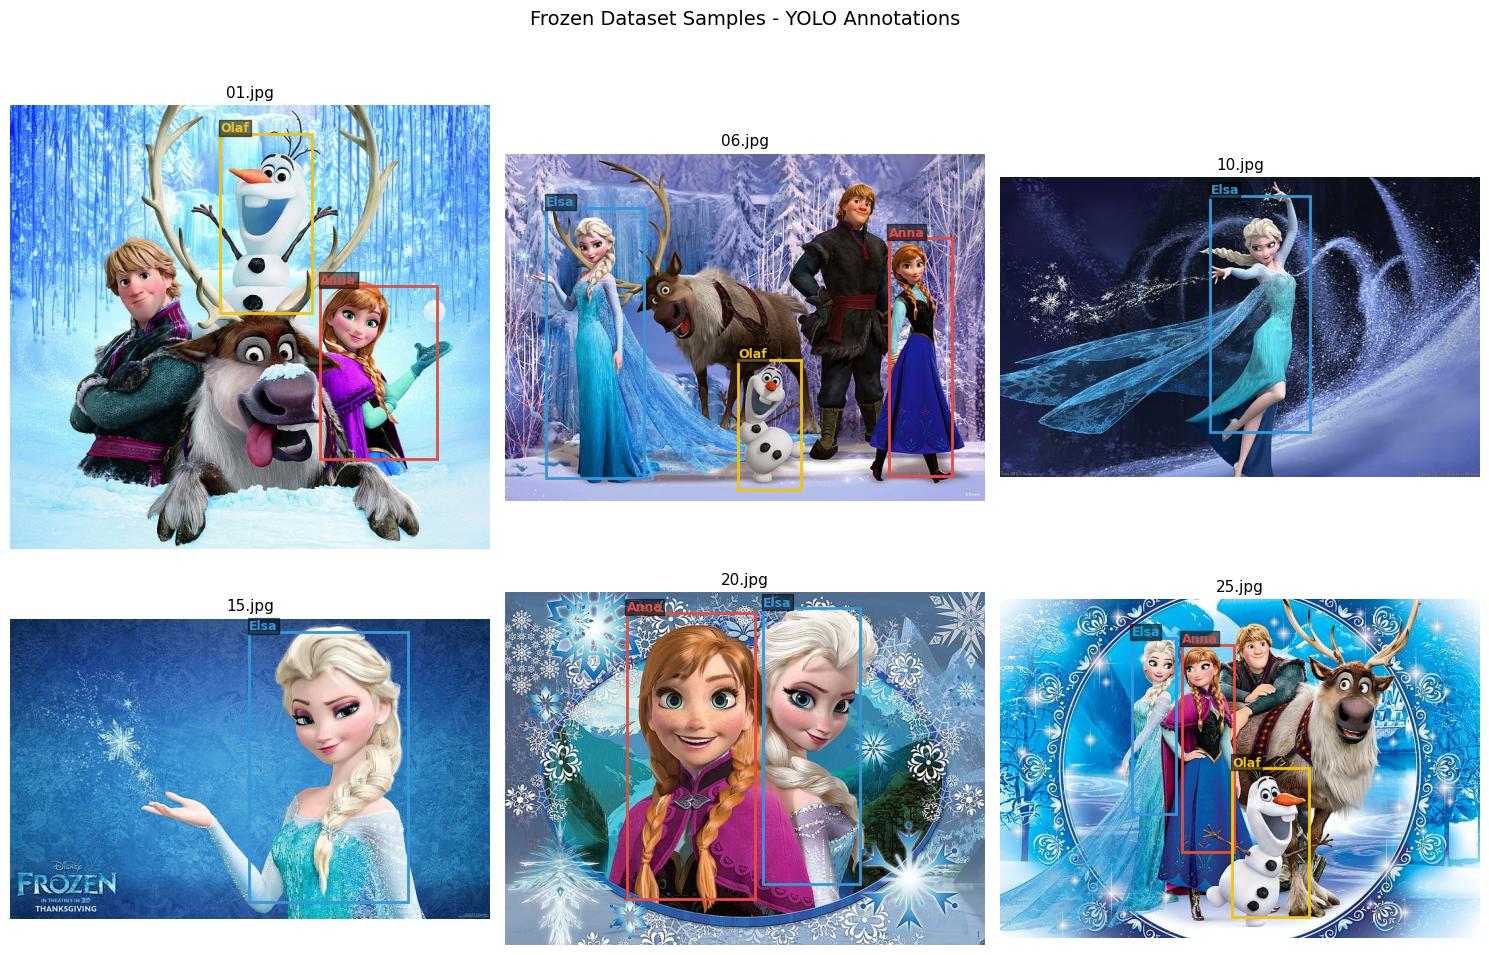

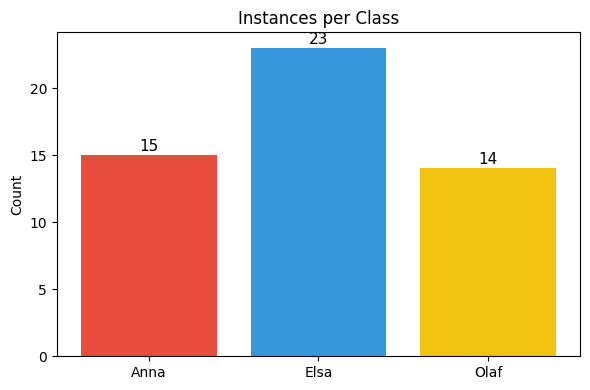

In [ ]:
# =============================================================================
#   데이터 EDA (Exploratory Data Analysis)
# - 학습 전 이미지·라벨 품질 확인
# - 그래프 타이틀은 matplotlib 한글 깨짐 방지를 위해 영문 사용
# =============================================================================

%matplotlib inline  # 노트북 셀 출력 바로 아래에 그래프 표시

from collections import Counter

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 클래스 정의 (frozen.yaml names 와 동일한 순서)
CLASS_NAMES = ["Anna", "Elsa", "Olaf"]
# EDA 시각화용 클래스별 색상 (bbox 테두리·막대 그래프)
CLASS_COLORS = {"Anna": "#E74C3C", "Elsa": "#3498DB", "Olaf": "#F1C40F"}

train_images_dir = DATASET_DIR / "images" / "train"
train_labels_dir = DATASET_DIR / "labels" / "train"


def load_yolo_labels(label_path: Path) -> list[tuple[int, float, float, float, float]]:
    """
    YOLO 형식 라벨 파일(.txt)을 파싱합니다.

    각 줄 형식: class_id  cx  cy  w  h  (모두 0~1 정규화 좌표)
    cx, cy : bbox 중심 / w, h : bbox 너비·높이 (이미지 대비 비율)
    """
    boxes = []
    if not label_path.exists():
        return boxes
    for line in label_path.read_text(encoding="utf-8").strip().splitlines():
        if not line.strip():
            continue
        cls_id, cx, cy, w, h = map(float, line.split())
        boxes.append((int(cls_id), cx, cy, w, h))
    return boxes


def show_labeled_image(ax, img_path: Path) -> None:
    """단일 이미지에 YOLO annotation bbox를 그려 matplotlib axes에 표시"""
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img)

    # 이미지 stem 과 동일한 이름의 .txt 라벨 파일 (예: 01.jpg → 01.txt)
    label_path = train_labels_dir / f"{img_path.stem}.txt"
    for cls_id, cx, cy, bw, bh in load_yolo_labels(label_path):
        name = CLASS_NAMES[cls_id]
        # YOLO 정규화 좌표 → 픽셀 좌표 (좌상단 x1,y1 + 너비·높이)
        x1 = (cx - bw / 2) * w
        y1 = (cy - bh / 2) * h
        color = CLASS_COLORS[name]
        ax.add_patch(
            patches.Rectangle(
                (x1, y1), bw * w, bh * h,
                linewidth=2, edgecolor=color, facecolor="none",
            )
        )
        ax.text(
            x1, max(y1 - 4, 0), name,
            color=color, fontsize=9, fontweight="bold",
            bbox=dict(facecolor="black", alpha=0.55, pad=1),
        )
    ax.set_title(img_path.name, fontsize=11)
    ax.axis("off")


# ── 1) 데이터셋 통계 출력 ─────────────────────────────────────
image_files = sorted(train_images_dir.glob("*.jpg"))
boxes_per_image = []
all_class_ids = []

for img_path in image_files:
    labels = load_yolo_labels(train_labels_dir / f"{img_path.stem}.txt")
    boxes_per_image.append(len(labels))
    all_class_ids.extend(cls_id for cls_id, *_ in labels)

class_counts = Counter(CLASS_NAMES[i] for i in all_class_ids)

print("=== Frozen Dataset Summary ===")
print(f"Images           : {len(image_files)}")
print(f"Total bboxes     : {len(all_class_ids)}")
print(f"Bboxes per image : {sum(boxes_per_image)/len(image_files):.1f} (avg)")
print(f"Bboxes per image : min={min(boxes_per_image)}, max={max(boxes_per_image)}")
print("\n=== Instances per Class ===")
for name in CLASS_NAMES:
    print(f"  {name:5s}: {class_counts.get(name, 0)}")

# ── 2) 샘플 이미지 6장 + annotation 시각화 ────────────────────
sample_names = ["01.jpg", "06.jpg", "10.jpg", "15.jpg", "20.jpg", "25.jpg"]
sample_paths = [train_images_dir / n for n in sample_names if (train_images_dir / n).exists()]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img_path in zip(axes.flat, sample_paths):
    show_labeled_image(ax, img_path)
for ax in axes.flat[len(sample_paths):]:
    ax.axis("off")
plt.suptitle("Frozen Dataset Samples - YOLO Annotations", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── 3) 클래스별 인스턴스 수 막대 그래프 ───────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
counts = [class_counts.get(name, 0) for name in CLASS_NAMES]
bars = ax.bar(CLASS_NAMES, counts, color=[CLASS_COLORS[n] for n in CLASS_NAMES])
ax.set_title("Instances per Class")
ax.set_ylabel("Count")
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(cnt), ha="center", fontsize=11)
plt.tight_layout()
plt.show()


## 3. YOLO26 모델 학습 (Train)

원본 YOLOv3 노트북 설정: `epochs=150`, `batch=8`, `imgsz=640`

### YOLOv3 대비 Anna가 누락될 수 있는 이유

| 항목 | YOLOv3 (구버전) | 이전 YOLO26n 기본 설정 |
|------|---------------------|------------------------|
| 모델 크기 | YOLOv3 (대형) | YOLO26**n** (2.5M — 매우 경량) |
| 옵티마이저 | SGD, lr=0.01 | AdamW 자동 선택 |
| 증강 | mosaic=1.0 | mosaic=1.0 (30장에 과함) |
| Anna conf (01.jpg) | 0.3 이상 검출 | **0.26** → conf=0.3에서 필터됨 |

<br>

> Anna는 **검출은 되지만 confidence가 0.3 미만**이라 `conf=0.3`에서만 보면 누락된 것처럼 보입니다.  
> 아래 **소규모 데이터셋 권장 설정**(`yolo26s` + 낮은 lr + 약한 증강 + freeze)으로 개선합니다.



In [ ]:
# =============================================================================
#   YOLO26 모델 학습 (Train)
# - 반드시 YOLO(MODEL_NAME)으로 새 모델 생성 후 train() 호출
#   (기존 predict용 model 객체로 train() 하면 가중치 일부만 로드됨)
# - RTX 3060 기준 yolo26s + 150 epoch : 약 10~15분 소요
# =============================================================================

train_model = YOLO(MODEL_NAME)  # COCO 사전학습 가중치 전체 로드

train_results = train_model.train(
    data=str(data_yaml),       # 1번 셀에서 생성한 frozen.yaml
    epochs=150,                # 13번 YOLOv3 노트북과 동일
    imgsz=640,                 # 입력 이미지 크기 (학습·추론 공통)
    batch=8,                   # GPU 메모리에 맞게 조절 (OOM 시 4로 낮춤)
    device=DEVICE,
    project=str(ROOT / "runs" / "detect"),  # 학습 결과 저장 루트
    name="yolo26_frozen",      # 실험 이름 → runs/detect/yolo26_frozen/
    exist_ok=True,             # 동일 이름 폴더 있으면 덮어쓰기
    patience=100,              # early stopping : val 개선 없으면 최대 100 epoch 대기
    plots=True,                # loss 곡선, labels.jpg 등 학습 그래프 저장
    # ── 소규모 커스텀 데이터셋(30장) 권장값 ── Ultralytics Fine-tuning Guide
    lr0=0.001,        # auto lr(AdamW)보다 낮게 → 소량 데이터 안정 학습
    mosaic=0.5,       # mosaic=1.0은 30장에서 과증강 → confidence 하락
    mixup=0.0,        # mixup 비활성 (소규모 데이터)
    copy_paste=0.0,   # copy-paste 비활성
    freeze=10,        # backbone 초기 10 layer 고정 → 과적합 완화
)

# best.pt : validation mAP 기준 최적 epoch 가중치
best_weights = Path(train_results.save_dir) / "weights" / "best.pt"
print(f"\n최적 가중치: {best_weights.resolve()}")

# 학습 직후 검증 — mAP50 > 0.9 이면 정상 학습된 것으로 볼 수 있음
val_metrics = YOLO(best_weights).val(data=str(data_yaml), imgsz=640, device=DEVICE)
print(f"mAP50-95: {val_metrics.box.map:.4f}")
print(f"mAP50   : {val_metrics.box.map50:.4f}")


New https://pypi.org/project/ultralytics/8.4.60 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.46  Python-3.11.9 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\MyCursorLab\06_Object_Detection\frozen\frozen.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosa

## 4. 학습된 모델로 이미지 예측 (Predict)

원본 노트북과 동일하게 `06.jpg`, `25.jpg`, `01.jpg`에 대해 예측합니다.  
`conf=0.3` 기준으로 Anna·Elsa·Olaf가 모두 나와야 정상입니다.


예측 대상: 06.jpg

image 1/1 c:\MyCursorLab\06_Object_Detection\frozen\images\train\06.jpg: 480x640 1 Anna, 1 Elsa, 1 Olaf, 110.3ms
Speed: 4.9ms preprocess, 110.3ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)
Results saved to C:\MyCursorLab\06_Object_Detection\runs\detect\yolo26_frozen_predict\06
탐지 수: 3
  - Olaf: 0.93
  - Elsa: 0.91
  - Anna: 0.85


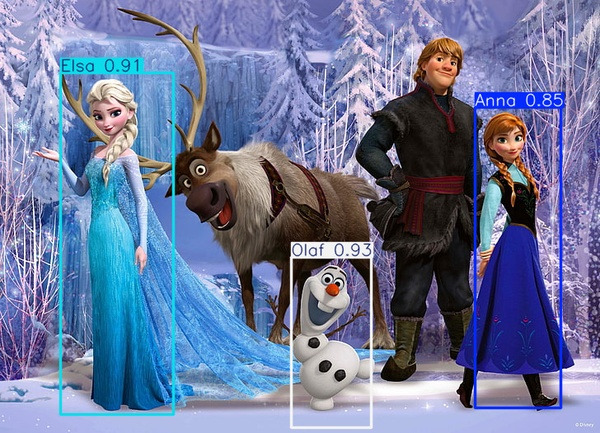

결과 저장 폴더: C:\MyCursorLab\06_Object_Detection\runs\detect\yolo26_frozen_predict\06
저장 파일    : C:\MyCursorLab\06_Object_Detection\runs\detect\yolo26_frozen_predict\06\06.jpg

예측 대상: 25.jpg
Results saved to C:\MyCursorLab\06_Object_Detection\runs\detect\yolo26_frozen_predict\25
탐지 수: 3
  - Olaf: 0.96
  - Elsa: 0.93
  - Anna: 0.61


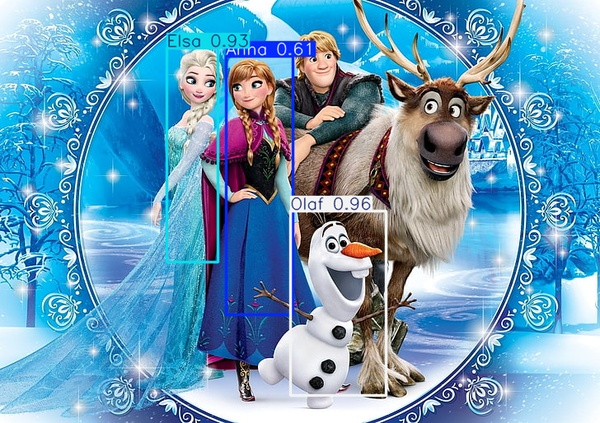

결과 저장 폴더: C:\MyCursorLab\06_Object_Detection\runs\detect\yolo26_frozen_predict\25
저장 파일    : C:\MyCursorLab\06_Object_Detection\runs\detect\yolo26_frozen_predict\25\25.jpg

예측 대상: 01.jpg
Results saved to C:\MyCursorLab\06_Object_Detection\runs\detect\yolo26_frozen_predict\01
탐지 수: 2
  - Olaf: 0.92
  - Anna: 0.91


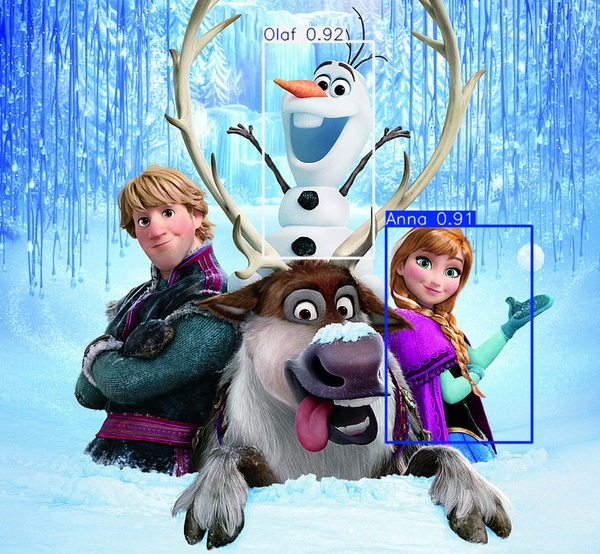

결과 저장 폴더: C:\MyCursorLab\06_Object_Detection\runs\detect\yolo26_frozen_predict\01
저장 파일    : C:\MyCursorLab\06_Object_Detection\runs\detect\yolo26_frozen_predict\01\01.jpg


In [ ]:
# =============================================================================
#   학습된 모델로 이미지 예측 (Predict)
# - 13번 YOLOv3 노트북과 동일하게 06.jpg, 25.jpg, 01.jpg 샘플 예측
# - conf=CONF_THRESH(0.3) 이상인 객체만 최종 출력
# =============================================================================

trained_model = YOLO(best_weights)  # 3번 셀에서 저장한 best.pt 로드
predict_dir = ROOT / "runs" / "detect" / "yolo26_frozen_predict"
train_images_dir = DATASET_DIR / "images" / "train"

# 원본 13번 노트북과 동일한 테스트 이미지 3장
sample_images = ["06.jpg", "25.jpg", "01.jpg"]

for img_name in sample_images:
    source_image = train_images_dir / img_name
    if not source_image.exists():
        print(f"[건너뜀] {source_image} 없음")
        continue

    print(f"\n{'='*50}")
    print(f"예측 대상: {img_name}")

    # predict() : 단일 이미지 추론, save=True 이면 bbox 그린 이미지 저장
    results = trained_model.predict(
        source=str(source_image),
        conf=CONF_THRESH,          # confidence 임계값 (0.3 미만은 제외)
        imgsz=640,                   # 학습과 동일한 입력 크기
        device=DEVICE,
        project=str(predict_dir),    # 결과 저장 상위 폴더
        name=Path(img_name).stem,    # 06.jpg → runs/.../06/ 하위 폴더
        exist_ok=True,
        save=True,                   # bbox가 그려진 jpg 저장
    )
    result = results[0]  # 단일 이미지이므로 첫 번째 Results 객체
    print(f"탐지 수: {len(result.boxes)}")

    if len(result.boxes) == 0:
        print("  검출 없음 — 3번 학습 셀을 다시 실행했는지 확인하세요.")
    else:
        for box in result.boxes:
            cls_id = int(box.cls[0])   # 클래스 인덱스 (0=Anna, 1=Elsa, 2=Olaf)
            conf = float(box.conf[0])  # confidence 점수 (0~1)
            print(f"  - {result.names[cls_id]}: {conf:.2f}")

    # conf=0.3에서 Anna 누락 시 진단: conf=0.1 기준 Anna 후보 confidence 출력
    low_conf = trained_model.predict(
        source=str(source_image), conf=0.1, imgsz=640, device=DEVICE, verbose=False
    )[0]
    anna_low = [
        float(b.conf) for b in low_conf.boxes if result.names[int(b.cls)] == "Anna"
    ]
    if not any(result.names[int(b.cls)] == "Anna" for b in result.boxes) and anna_low:
        print(f"  [참고] conf=0.1 기준 Anna 후보: {max(anna_low):.2f} — 3번 학습 설정 확인")

    show_result(result, img_name)  # 1번 셀에서 정의한 노트북 표시 함수


## 5. (선택) 전체 학습 이미지 일괄 예측

30장 전체에 대해 예측 결과를 저장합니다.

In [ ]:
# =============================================================================
# (선택) 전체 학습 이미지 30장 일괄 예측
# - source에 폴더 경로를 넘기면 내부 jpg를 순차 처리
# - 결과: runs/detect/yolo26_frozen_predict/all_train_images/
# =============================================================================

all_results = trained_model.predict(
    source=str(train_images_dir),  # 폴더 내 모든 이미지 일괄 추론
    conf=CONF_THRESH,
    imgsz=640,
    device=DEVICE,
    project=str(predict_dir),
    name="all_train_images",
    exist_ok=True,
    save=True,
)

total_detections = sum(len(r.boxes) for r in all_results)
print(f"처리 이미지: {len(all_results)}장")
print(f"총 탐지 수 : {total_detections}개")
print(f"결과 저장  : {Path(all_results[0].save_dir).resolve()}")


Results saved to C:\MyCursorLab\06_Object_Detection\runs\detect\yolo26_frozen_predict\all_train_images
처리 이미지: 30장
총 탐지 수 : 54개
결과 저장  : C:\MyCursorLab\06_Object_Detection\runs\detect\yolo26_frozen_predict\all_train_images


## 6. (선택) CLI 명령어

터미널에서도 동일한 작업을 수행할 수 있습니다.

```bash
# 학습
yolo train model=yolo26n.pt data=frozen/frozen.yaml epochs=150 imgsz=640 batch=8 device=0

# 예측
yolo predict model=runs/detect/yolo26_frozen/weights/best.pt source=frozen/images/train/06.jpg conf=0.3
```

### [1] CVAT Custom 이미지 라벨링 작업  :  이미지와 Annotation
#### object detection annotation tool 구글 검색
- CVAT ,  https://www.cvat.ai/
- Yolo Marker , https://github.com/AlexeyAB/Yolo_mark  , https://ctkim.tistory.com/82
- keymake,  https://keymakr.com/  ,ROTATED BOUNDING BOXES 지원

<br>
사용법 설명 :
https://velog.io/@happy_quokka/Data-Labeling-Tool-CVAT

### CVAT 
 - https://www.cvat.ai/ 에 접속, 구글계정으로 로그인(자동 가입)
 - Task : Creat a new task
 - Task Name : Frozen_30_image을 입력
 - Label 생성   
    'Anna', 'Elsa', 'Olaf' 
 - 업로드할 Image 선택(드래그)  
 - [Submit & Open] 버튼 클릭    
 - Jobs : annotation 작업 수행
 - 좌측 사각형 아이콘 : Draw new rectangle
 - label선택 : [shape]버튼, 단축키 'N'
 - 작업 완료후 [Save] 버튼으로 저장
 - Annotation 파일 다운로드
 : Menu --> Export job dataset--> format을 'YOLO 1.1'로 선택 --> [OK] 버튼
 
 [파일 구조]  
 /frozen/images/train/ : 이미지 파일들    
 /frozen/labels/train/ : annotaion 파일들     
 파일 압축후 Colab으로 업로드 하고 Colab에서 압축해제